In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.read_csv('../data/gdp_percapita.csv')

,Country or Area,Year,Value,Value Footnotes
0,Afghanistan,2023,1983.812620,NaN
1,Afghanistan,2022,1981.710168,NaN
2,Afghanistan,2021,2144.166570,NaN
3,Afghanistan,2020,2769.685745,NaN
4,Afghanistan,2019,2927.245144,NaN
...,...,...,...,...
8460,Zimbabwe,1994,6010.742417,NaN
8461,Zimbabwe,1993,5509.083113,NaN
8462,Zimbabwe,1992,5532.037403,NaN
8463,Zimbabwe,1991,6254.274735,NaN


In [3]:
gdp_df = pd.read_csv('../data/gdp_percapita.csv')

In [4]:
gdp_df

,Country or Area,Year,Value,Value Footnotes
0,Afghanistan,2023,1983.812620,NaN
1,Afghanistan,2022,1981.710168,NaN
2,Afghanistan,2021,2144.166570,NaN
3,Afghanistan,2020,2769.685745,NaN
4,Afghanistan,2019,2927.245144,NaN
...,...,...,...,...
8460,Zimbabwe,1994,6010.742417,NaN
8461,Zimbabwe,1993,5509.083113,NaN
8462,Zimbabwe,1992,5532.037403,NaN
8463,Zimbabwe,1991,6254.274735,NaN


In [5]:
gdp_df.head()

,Country or Area,Year,Value,Value Footnotes
0,Afghanistan,2023,1983.812620,NaN
1,Afghanistan,2022,1981.710168,NaN
2,Afghanistan,2021,2144.166570,NaN
3,Afghanistan,2020,2769.685745,NaN
4,Afghanistan,2019,2927.245144,NaN


In [6]:
gdp_df.tail()

,Country or Area,Year,Value,Value Footnotes
8460,Zimbabwe,1994,6010.742417,NaN
8461,Zimbabwe,1993,5509.083113,NaN
8462,Zimbabwe,1992,5532.037403,NaN
8463,Zimbabwe,1991,6254.274735,NaN
8464,Zimbabwe,1990,6082.842451,NaN


#### 5. How many rows and columns are in 'gdp_df'? What are the data types of each column?

In [7]:
gdp_df.columns

Index(['Country or Area', 'Year', 'Value', 'Value Footnotes'], dtype='object')

In [8]:
gdp_df.shape

(8465, 4)

8465 rows, 4 columns

In [9]:
gdp_df.dtypes

Country or Area     object
Year                 int64
Value              float64
Value Footnotes    float64
dtype: object

#### 6. Drop the `Value Footnotes` column and rename the remaining three to 'Country', 'Year', and 'GDP_Per_Capita'.

In [10]:
gdp_df = gdp_df.drop(columns = 'Value Footnotes')
gdp_df

,Country or Area,Year,Value
0,Afghanistan,2023,1983.812620
1,Afghanistan,2022,1981.710168
2,Afghanistan,2021,2144.166570
3,Afghanistan,2020,2769.685745
4,Afghanistan,2019,2927.245144
...,...,...,...
8460,Zimbabwe,1994,6010.742417
8461,Zimbabwe,1993,5509.083113
8462,Zimbabwe,1992,5532.037403
8463,Zimbabwe,1991,6254.274735


In [11]:
gdp_df.rename(columns = {'Country or Area': 'Country','Value':'GDP_Per_Capita'})

,Country,Year,GDP_Per_Capita
0,Afghanistan,2023,1983.812620
1,Afghanistan,2022,1981.710168
2,Afghanistan,2021,2144.166570
3,Afghanistan,2020,2769.685745
4,Afghanistan,2019,2927.245144
...,...,...,...
8460,Zimbabwe,1994,6010.742417
8461,Zimbabwe,1993,5509.083113
8462,Zimbabwe,1992,5532.037403
8463,Zimbabwe,1991,6254.274735


In [12]:
gdp_df = gdp_df.rename(columns = {'Country or Area': 'Country','Value':'GDP_Per_Capita'})

#### 7. How many countries have data for all years? Which countries are missing many years of data? Look at the number of observations per year. What do you notice? 

In [13]:
gdp_df

,Country,Year,GDP_Per_Capita
0,Afghanistan,2023,1983.812620
1,Afghanistan,2022,1981.710168
2,Afghanistan,2021,2144.166570
3,Afghanistan,2020,2769.685745
4,Afghanistan,2019,2927.245144
...,...,...,...
8460,Zimbabwe,1994,6010.742417
8461,Zimbabwe,1993,5509.083113
8462,Zimbabwe,1992,5532.037403
8463,Zimbabwe,1991,6254.274735


In [14]:
gdp_df['Year'].value_counts()
## tells me the # of operations per year

Year
2015    247
2021    247
2020    247
2019    247
2018    247
2017    247
2016    247
2022    247
2014    247
2013    247
2012    246
2011    246
2010    246
2009    246
2008    245
2023    245
2007    243
2006    242
2005    241
2004    241
2003    241
2002    241
2001    240
2000    240
1997    238
1998    238
1999    238
2024    236
1996    236
1995    236
1994    235
1993    234
1992    234
1991    234
1990    233
Name: count, dtype: int64

In [15]:
#### look at the # of operations per year, what do you notice? I notice that there is a max of 247 oberservations per year and a min of 233.

In [16]:
## gives # of observations per country
obs_country = gdp_df['Country'].value_counts().to_frame().reset_index()
obs_country

,Country,count
0,Latin America & Caribbean (excluding high income),35
1,Nicaragua,35
2,"Middle East, North Africa, Afghanistan & Pakis...",35
3,Middle income,35
4,Moldova,35
...,...,...
242,Cayman Islands,18
243,Kosovo,17
244,Faroe Islands,17
245,Sint Maarten (Dutch part),16


In [17]:
## this will tell me the number of years recorded in the dataset
num_years = gdp_df['Year'].value_counts().shape[0]
num_years

35

In [18]:
## gives # of countries in dataset
num_countries = obs_country.shape[0]
num_countries

247

In [19]:
# another instance of how to use .loc instead of .query
lacking_countries1 = obs_country.loc[obs_country['count'] < num_years]
lacking_countries1

,Country,count
226,Lebanon,34
227,Tuvalu,34
228,"Somalia, Fed. Rep.",34
229,Tonga,34
230,Bhutan,34
231,Greenland,34
232,Palau,34
233,Syrian Arab Republic,33
234,West Bank and Gaza,31
235,Serbia,30


In [20]:
## gives the countries in the dataset that have less than the max amount of years
lacking_countries = obs_country.query("count < @num_years")
lacking_countries

,Country,count
226,Lebanon,34
227,Tuvalu,34
228,"Somalia, Fed. Rep.",34
229,Tonga,34
230,Bhutan,34
231,Greenland,34
232,Palau,34
233,Syrian Arab Republic,33
234,West Bank and Gaza,31
235,Serbia,30


In [21]:
countries_md = lacking_countries.shape[0]
countries_md

21

In [22]:
## gives me the # of total countries - the # of countries with missing years of data
num_countries - countries_md

226

##### 226 countries have data for all years, 21 do not

#### 8. Create a histogram, a density plot, a boxplot, and a violin plot for GDP per capita for the year 2020.

In [23]:
gdp_df

,Country,Year,GDP_Per_Capita
0,Afghanistan,2023,1983.812620
1,Afghanistan,2022,1981.710168
2,Afghanistan,2021,2144.166570
3,Afghanistan,2020,2769.685745
4,Afghanistan,2019,2927.245144
...,...,...,...
8460,Zimbabwe,1994,6010.742417
8461,Zimbabwe,1993,5509.083113
8462,Zimbabwe,1992,5532.037403
8463,Zimbabwe,1991,6254.274735


In [24]:
df1_2020 = gdp_df.loc[gdp_df['Year'] == 2020]
df1_2020

,Country,Year,GDP_Per_Capita
3,Afghanistan,2020,2769.685745
28,Africa Eastern and Southern,2020,3978.931395
63,Africa Western and Central,2020,5687.849988
98,Albania,2020,15659.588696
133,Algeria,2020,14194.155748
...,...,...,...
8310,Virgin Islands (US),2020,45055.782930
8333,West Bank and Gaza,2020,5423.682547
8364,World,2020,18803.068884
8399,Zambia,2020,3391.595412


In [25]:
df_2020 = gdp_df.query("Year == 2020")
df_2020

,Country,Year,GDP_Per_Capita
3,Afghanistan,2020,2769.685745
28,Africa Eastern and Southern,2020,3978.931395
63,Africa Western and Central,2020,5687.849988
98,Albania,2020,15659.588696
133,Algeria,2020,14194.155748
...,...,...,...
8310,Virgin Islands (US),2020,45055.782930
8333,West Bank and Gaza,2020,5423.682547
8364,World,2020,18803.068884
8399,Zambia,2020,3391.595412


<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

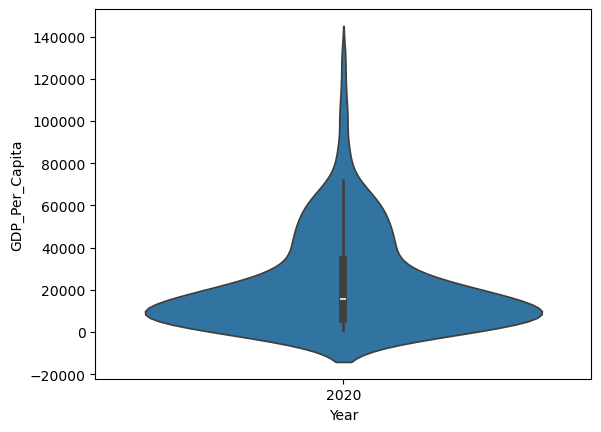

In [26]:
sns.violinplot(x=df_2020["Year"], y=df_2020["GDP_Per_Capita"])

<Axes: xlabel='GDP_Per_Capita', ylabel='Density'>

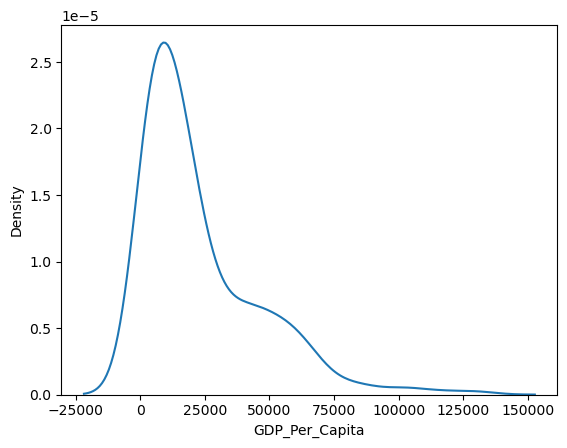

In [27]:
sns.kdeplot(df_2020['GDP_Per_Capita'])

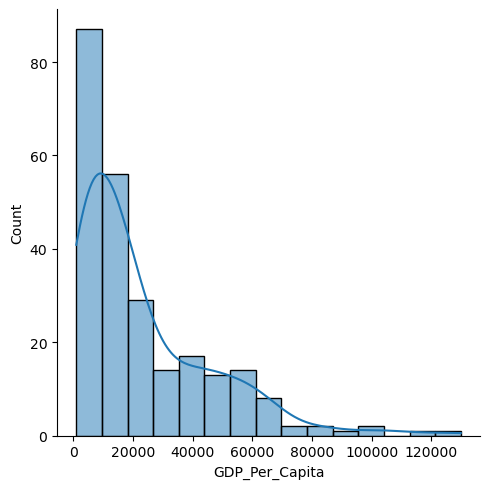

In [28]:
sns.displot( data=df_2020["GDP_Per_Capita"], kde=True )

<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

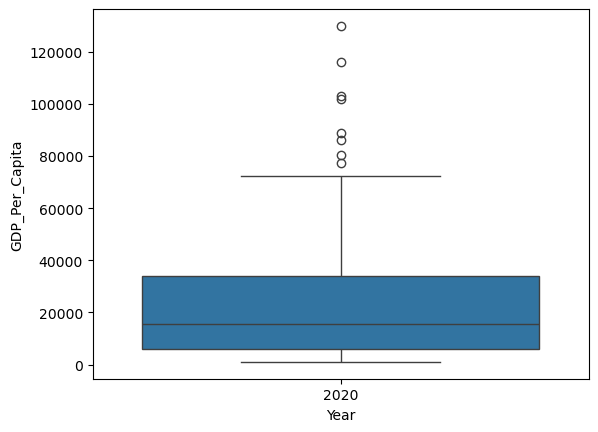

In [29]:
sns.boxplot( x=df_2020["Year"], y=df_2020["GDP_Per_Capita"] )

##### I think boxplots might be able to help you label specific outliers. It also gives you many common statistical measures. Violin plots add an extra dimension to boxplots, showing quartiles visually to scale. 

##### Density plots are probably the most straight-forward way to contextualize where in a range most of the data sits. Histograms seems useful for defining relevant intervals and measuring data by those intervals and showing them to scale.

#### 9. What was the median GDP per capita value in 2020?

In [30]:
df_2020.describe()

,Year,GDP_Per_Capita
count,247.0,247.000000
mean,2020.0,23118.025650
std,0.0,22915.365686
min,2020.0,1030.770264
25%,2020.0,6046.008968
50%,2020.0,15399.308958
75%,2020.0,33899.203031
max,2020.0,129865.629988


##### Median is 15399.308958

#### Compare GDP Per Capita for the years 1990, 2000, 2010, and 2020. Start by subsetting your data to just these 4 years into a new DataFrame named gdp_decades. Create a boxplot, a barplot, a scatterplot, and a scatterplot with a trend line.

In [31]:
gdp_df

,Country,Year,GDP_Per_Capita
0,Afghanistan,2023,1983.812620
1,Afghanistan,2022,1981.710168
2,Afghanistan,2021,2144.166570
3,Afghanistan,2020,2769.685745
4,Afghanistan,2019,2927.245144
...,...,...,...
8460,Zimbabwe,1994,6010.742417
8461,Zimbabwe,1993,5509.083113
8462,Zimbabwe,1992,5532.037403
8463,Zimbabwe,1991,6254.274735


In [32]:
gdp_decades = gdp_df.query("Year in [1990, 2000, 2010, 2020]").sort_values(by = 'Year').reset_index(drop=True)
gdp_decades

,Country,Year,GDP_Per_Capita
0,Zimbabwe,1990,6082.842451
1,Sierra Leone,1990,2703.599187
2,Europe & Central Asia,1990,28177.752634
3,Euro area,1990,37825.251291
4,Singapore,1990,45567.790389
...,...,...,...
961,Guatemala,2020,11097.150412
962,Qatar,2020,103061.899445
963,Guinea,2020,3630.993306
964,Puerto Rico (US),2020,40171.386688


<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

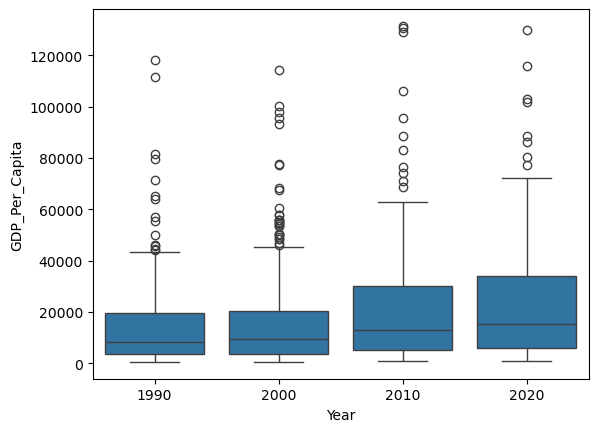

In [33]:
sns.boxplot( x=gdp_decades["Year"], y=gdp_decades["GDP_Per_Capita"] )

<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

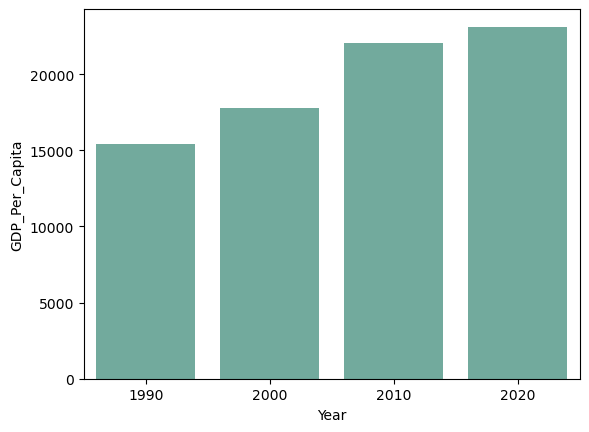

In [34]:
sns.barplot(
    x="Year", 
    y="GDP_Per_Capita", 
    data=gdp_decades, 
    errorbar=None, 
    color='#69b3a2')

<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

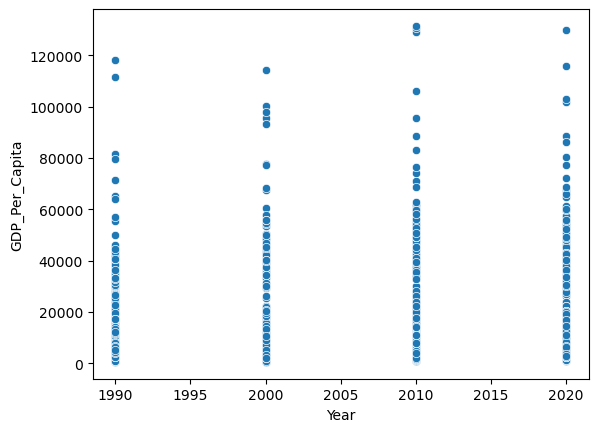

In [35]:
sns.scatterplot(data=gdp_decades, x="Year", y="GDP_Per_Capita")

<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

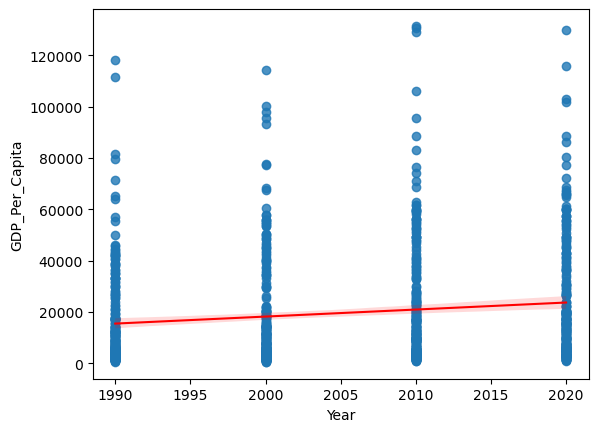

In [36]:
sns.regplot(
    x=gdp_decades["Year"],
    y=gdp_decades["GDP_Per_Capita"],
    line_kws={"color": "red", "linewidth": 1.5}
)

##### I think the bar plot is the most intuitive easy to understand chart of them all. It gives a clear demonstration of the rise in GDP per capita over time. The boxplot may be the best chart for an analyst. It is somewhat difficult to understand for your average person. The Scatterplots are somewhat better, but a violin chart would probably be better here to visualize density of data points. The trendline helps some, but it would be much better if there were more years and GDP Per Capita was more spread out.

#### 11. Which country was the first to have a GDP per capita greater than $100,000?

In [37]:
gdp_df

,Country,Year,GDP_Per_Capita
0,Afghanistan,2023,1983.812620
1,Afghanistan,2022,1981.710168
2,Afghanistan,2021,2144.166570
3,Afghanistan,2020,2769.685745
4,Afghanistan,2019,2927.245144
...,...,...,...
8460,Zimbabwe,1994,6010.742417
8461,Zimbabwe,1993,5509.083113
8462,Zimbabwe,1992,5532.037403
8463,Zimbabwe,1991,6254.274735


In [38]:
gdp_100k = gdp_df.query("GDP_Per_Capita > 100000")
gdp_100k

,Country,Year,GDP_Per_Capita
794,Bermuda,2024,109311.936941
795,Bermuda,2023,103052.348368
807,Bermuda,2011,101989.927296
808,Bermuda,2010,105968.875104
809,Bermuda,2009,108962.816946
...,...,...,...
8058,United Arab Emirates,1994,102456.104720
8059,United Arab Emirates,1993,100422.631522
8060,United Arab Emirates,1992,104206.754891
8061,United Arab Emirates,1991,106266.193694


In [39]:
gdp_100k.sort_values(by = 'Year')

,Country,Year,GDP_Per_Capita
8062,United Arab Emirates,1990,111377.046890
1037,Brunei Darussalam,1990,118163.683370
8061,United Arab Emirates,1991,106266.193694
1036,Brunei Darussalam,1991,118220.683595
8060,United Arab Emirates,1992,104206.754891
...,...,...,...
6774,Singapore,2024,132569.525226
4625,Luxembourg,2024,128475.279803
4660,"Macao SAR, China",2024,111693.502831
6367,Qatar,2024,110889.792702


##### The United Arab Emirates

#### Which country had the highest GDP per capita in 2020? Create a plot showing how this country's GDP per capita has changed over the timespan of the dataset.

In [40]:
gdp_df

,Country,Year,GDP_Per_Capita
0,Afghanistan,2023,1983.812620
1,Afghanistan,2022,1981.710168
2,Afghanistan,2021,2144.166570
3,Afghanistan,2020,2769.685745
4,Afghanistan,2019,2927.245144
...,...,...,...
8460,Zimbabwe,1994,6010.742417
8461,Zimbabwe,1993,5509.083113
8462,Zimbabwe,1992,5532.037403
8463,Zimbabwe,1991,6254.274735


In [41]:
# returns df ordered by the highest GDP Per Capita in 2020: Luxembourg at the top.
gdp_df.query("Year == 2020").sort_values(by = 'GDP_Per_Capita', ascending = False)

,Country,Year,GDP_Per_Capita
4629,Luxembourg,2020,129865.629988
6778,Singapore,2020,115893.042396
6371,Qatar,2020,103061.899445
3668,Ireland,2020,101968.554362
798,Bermuda,2020,88618.083068
...,...,...,...
5357,Mozambique,2020,1466.124765
6969,"Somalia, Fed. Rep.",2020,1396.055447
1620,"Congo, Democratic Republic of",2020,1361.027911
1375,Central African Republic,2020,1136.570530


In [42]:
lux_df = gdp_df.query("Country == 'Luxembourg'")
lux_df

,Country,Year,GDP_Per_Capita
4625,Luxembourg,2024,128475.279803
4626,Luxembourg,2023,130048.920388
4627,Luxembourg,2022,132570.826463
4628,Luxembourg,2021,136772.443753
4629,Luxembourg,2020,129865.629988
4630,Luxembourg,2019,132724.752744
4631,Luxembourg,2018,131733.884649
4632,Luxembourg,2017,132169.834045
4633,Luxembourg,2016,133661.649729
4634,Luxembourg,2015,130097.256180


<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

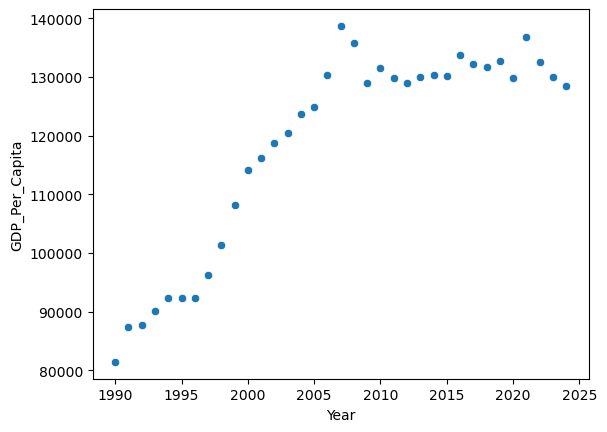

In [43]:
sns.scatterplot(data=lux_df, x="Year", y="GDP_Per_Capita")

#### **Bonus question:** Is it true in general that countries had a higher GDP per capita in 2020 than in 1990? Which countries had lower GDP per capita in 2020 than in 1990?

In [44]:
gdp_df

,Country,Year,GDP_Per_Capita
0,Afghanistan,2023,1983.812620
1,Afghanistan,2022,1981.710168
2,Afghanistan,2021,2144.166570
3,Afghanistan,2020,2769.685745
4,Afghanistan,2019,2927.245144
...,...,...,...
8460,Zimbabwe,1994,6010.742417
8461,Zimbabwe,1993,5509.083113
8462,Zimbabwe,1992,5532.037403
8463,Zimbabwe,1991,6254.274735


In [45]:
decades_90_20 = gdp_df.query("Year in [1990, 2020]").sort_values(by = 'Year').reset_index(drop=True)
decades_90_20

,Country,Year,GDP_Per_Capita
0,Latin America & Caribbean,1990,12426.249644
1,Malawi,1990,1047.464364
2,Madagascar,1990,1968.272398
3,"Macao SAR, China",1990,55300.744265
4,Luxembourg,1990,81450.572406
...,...,...,...
475,Croatia,2020,30917.369008
476,Maldives,2020,14242.975070
477,Malaysia,2020,29200.452632
478,Marshall Islands,2020,6417.184412


<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

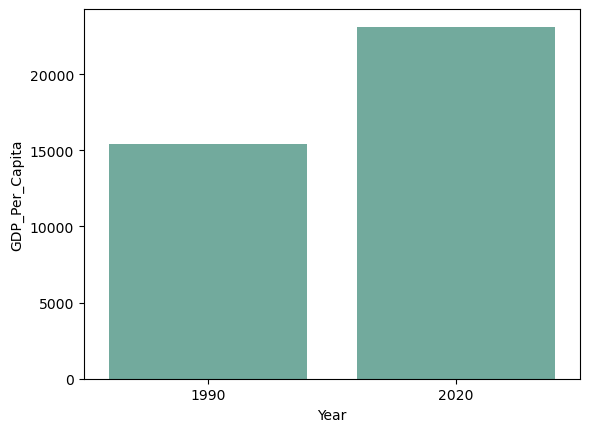

In [46]:
sns.barplot(
    x="Year", 
    y="GDP_Per_Capita", 
    data=decades_90_20, 
    errorbar=None, 
    color='#69b3a2')

<Axes: xlabel='Year', ylabel='GDP_Per_Capita'>

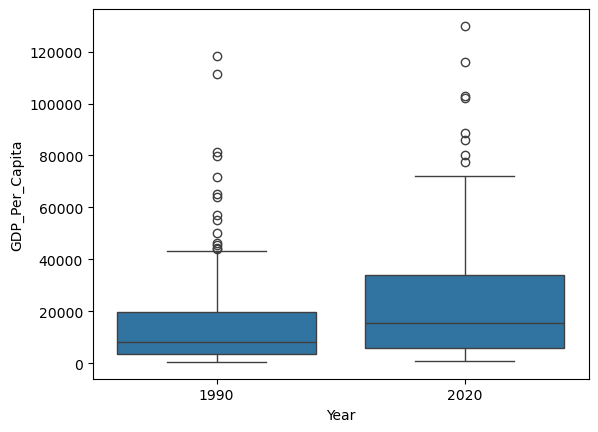

In [47]:
sns.boxplot( x=decades_90_20["Year"], y=decades_90_20["GDP_Per_Capita"] )

In [48]:
decades_90 = gdp_df.loc[gdp_df['Year'] == 1990]
decades_90

,Country,Year,GDP_Per_Capita
58,Africa Eastern and Southern,1990,3519.317545
93,Africa Western and Central,1990,4159.732102
128,Albania,1990,5291.156834
163,Algeria,1990,11728.545729
198,Andorra,1990,50036.300776
...,...,...,...
8272,Vanuatu,1990,3101.680551
8307,Viet Nam,1990,2467.964601
8394,World,1990,11250.325176
8429,Zambia,1990,2425.111287


In [49]:
decades_20 = gdp_df.loc[gdp_df['Year'] == 2020]
decades_20

,Country,Year,GDP_Per_Capita
3,Afghanistan,2020,2769.685745
28,Africa Eastern and Southern,2020,3978.931395
63,Africa Western and Central,2020,5687.849988
98,Albania,2020,15659.588696
133,Algeria,2020,14194.155748
...,...,...,...
8310,Virgin Islands (US),2020,45055.782930
8333,West Bank and Gaza,2020,5423.682547
8364,World,2020,18803.068884
8399,Zambia,2020,3391.595412


In [50]:
decades_90_20

,Country,Year,GDP_Per_Capita
0,Latin America & Caribbean,1990,12426.249644
1,Malawi,1990,1047.464364
2,Madagascar,1990,1968.272398
3,"Macao SAR, China",1990,55300.744265
4,Luxembourg,1990,81450.572406
...,...,...,...
475,Croatia,2020,30917.369008
476,Maldives,2020,14242.975070
477,Malaysia,2020,29200.452632
478,Marshall Islands,2020,6417.184412


In [51]:
decades_90_20.loc[decades_90_20['Year'] == 1990, 'GDP_Per_Capita'].reset_index(drop=True)

0       12426.249644
1        1047.464364
2        1968.272398
3       55300.744265
4       81450.572406
           ...      
228      3519.317545
229      1481.252551
230      1460.276459
231    118163.683370
232     38655.885684
Name: GDP_Per_Capita, Length: 233, dtype: float64

#### 14. Read in the internet use dataset into a DataFrame named `internet_df`. Take a look at the top and bottom few rows to make sure that it has been read in correctly. Also, check the datatypes of the columns.

In [54]:
internet_df = pd.read_csv(
    '../data/internet_usage.csv',
    skipfooter=298,
    on_bad_lines="skip",
    engine="python"
)

internet_df

,Country or Area,Year,Value,Value Footnotes
0,Afghanistan,2019,17.600000,1
1,Afghanistan,2018,16.800000,2
2,Afghanistan,2017,13.500000,3
3,Afghanistan,2016,11.000000,4
4,Afghanistan,2015,8.260000,4
...,...,...,...,...
6078,Zimbabwe,1997,0.033080,NaN
6079,Zimbabwe,1996,0.016790,NaN
6080,Zimbabwe,1995,0.007684,NaN
6081,Zimbabwe,1994,0.001739,NaN


In [55]:
internet_df.head()

,Country or Area,Year,Value,Value Footnotes
0,Afghanistan,2019,17.60,1
1,Afghanistan,2018,16.80,2
2,Afghanistan,2017,13.50,3
3,Afghanistan,2016,11.00,4
4,Afghanistan,2015,8.26,4


In [56]:
internet_df.tail()

,Country or Area,Year,Value,Value Footnotes
6078,Zimbabwe,1997,0.033080,NaN
6079,Zimbabwe,1996,0.016790,NaN
6080,Zimbabwe,1995,0.007684,NaN
6081,Zimbabwe,1994,0.001739,NaN
6082,Zimbabwe,1990,0.000000,NaN


In [57]:
internet_df.dtypes

Country or Area     object
Year                 int64
Value              float64
Value Footnotes     object
dtype: object

#### 15. Drop the `Value Footnotes` column and rename the remaining three to 'Country', 'Year', and 'Internet_Users_Pct'.

In [58]:
internet_df

,Country or Area,Year,Value,Value Footnotes
0,Afghanistan,2019,17.600000,1
1,Afghanistan,2018,16.800000,2
2,Afghanistan,2017,13.500000,3
3,Afghanistan,2016,11.000000,4
4,Afghanistan,2015,8.260000,4
...,...,...,...,...
6078,Zimbabwe,1997,0.033080,NaN
6079,Zimbabwe,1996,0.016790,NaN
6080,Zimbabwe,1995,0.007684,NaN
6081,Zimbabwe,1994,0.001739,NaN


In [59]:
internet_df = internet_df.drop(columns = 'Value Footnotes').rename(columns = {'Country or Area': 'Country', 'Value': 'Internet_Users_Pct'})
internet_df

,Country,Year,Internet_Users_Pct
0,Afghanistan,2019,17.600000
1,Afghanistan,2018,16.800000
2,Afghanistan,2017,13.500000
3,Afghanistan,2016,11.000000
4,Afghanistan,2015,8.260000
...,...,...,...
6078,Zimbabwe,1997,0.033080
6079,Zimbabwe,1996,0.016790
6080,Zimbabwe,1995,0.007684
6081,Zimbabwe,1994,0.001739


#### 16. Look at the number of observations in this dataset per year. What do you notice?

In [60]:
internet_df['Year'].value_counts()

Year
1990    226
2007    217
2011    214
2008    214
2009    214
2002    214
2006    212
2001    212
2005    212
2004    210
2000    210
2010    209
2012    209
2003    208
1999    207
2016    206
2017    205
2014    204
2015    203
2013    203
1998    195
1997    188
2021    186
2020    186
2019    185
2022    184
1996    177
2018    174
1995    141
1994     92
1993     66
1992     50
1991     39
2023     11
Name: count, dtype: int64

##### There is a wide range. Likely due to the fact of many countries beginning to develop internet usage since the 90s.

#### 17. What is the first year to have a non-zero internet users percentage value?

In [61]:
internet_df

,Country,Year,Internet_Users_Pct
0,Afghanistan,2019,17.600000
1,Afghanistan,2018,16.800000
2,Afghanistan,2017,13.500000
3,Afghanistan,2016,11.000000
4,Afghanistan,2015,8.260000
...,...,...,...
6078,Zimbabwe,1997,0.033080
6079,Zimbabwe,1996,0.016790
6080,Zimbabwe,1995,0.007684
6081,Zimbabwe,1994,0.001739


In [62]:
internet_df.sort_values(by = 'Year').query('Internet_Users_Pct > 0')

,Country,Year,Internet_Users_Pct
2796,Israel,1990,0.110774
2829,Italy,1990,0.017545
5150,Spain,1990,0.012874
543,Belgium,1990,0.001007
2892,Japan,1990,0.020294
...,...,...,...
3141,Latvia,2023,92.187900
1656,Ecuador,2023,72.694300
1537,Denmark,2023,98.775600
340,Azerbaijan,2023,88.000000


##### 1990

#### 18. How does the distribution of internet users percent differ for 2000 and 2014?

In [63]:
df_00_14 = internet_df.query("Year in [2000, 2014]")
df_00_14

,Country,Year,Internet_Users_Pct
5,Afghanistan,2014,7.000000
28,Albania,2014,54.300000
42,Albania,2000,0.114097
57,Algeria,2014,29.500000
71,Algeria,2000,0.491706
...,...,...,...
6017,Yemen,2000,0.082500
6031,Zambia,2014,6.500000
6045,Zambia,2000,0.191072
6061,Zimbabwe,2014,16.364700


<Axes: xlabel='Year', ylabel='Internet_Users_Pct'>

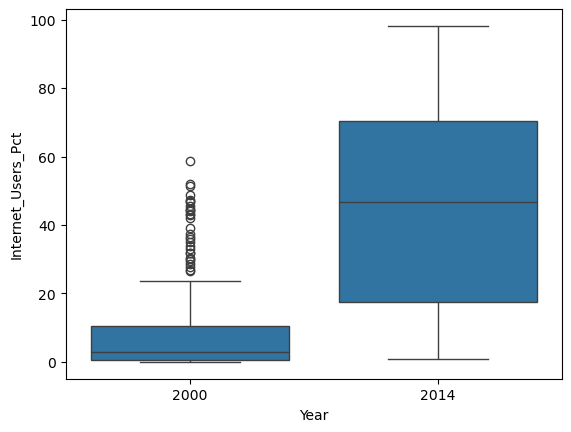

In [64]:
sns.boxplot( x=df_00_14["Year"], y=df_00_14["Internet_Users_Pct"] )

##### there are way more countries with internet use in the 20-70% range in 2014. In 2000, internet usages was mostly a range between 0-25% with most countries being at or below 15%

####  19. For how many countries was the percentage of internet users below 5% in 2014?

In [65]:
internet_df

,Country,Year,Internet_Users_Pct
0,Afghanistan,2019,17.600000
1,Afghanistan,2018,16.800000
2,Afghanistan,2017,13.500000
3,Afghanistan,2016,11.000000
4,Afghanistan,2015,8.260000
...,...,...,...
6078,Zimbabwe,1997,0.033080
6079,Zimbabwe,1996,0.016790
6080,Zimbabwe,1995,0.007684
6081,Zimbabwe,1994,0.001739


In [66]:
internet_df.query('Year == 2014 and Internet_Users_Pct < 5')

,Country,Year,Internet_Users_Pct
873,Burundi,2014,1.04239
1033,Central African Republic,2014,2.70000
1061,Chad,2014,2.90000
1517,Democratic Republic of the Congo,2014,3.00000
1782,Eritrea,2014,0.99000
2451,Guinea-Bissau,2014,3.32000
3364,Madagascar,2014,3.70000
4073,Niger,2014,1.24868
5055,Somalia,2014,1.63000
5116,South Sudan,2014,2.60000


In [67]:
# returns the # of countries with internet user pct < 5
internet_df.query('Year == 2014 and Internet_Users_Pct < 5').shape[1]

3

In [68]:
# Does the same thing as query but is more consistent with the rest of python workflows
internet_df.loc[(internet_df['Internet_Users_Pct'] < 5) & (internet_df['Year']==2014)].shape[1]

3

#### 20. Merge the two DataFrames to one. Do this in a way that keeps **all rows** from each of the two DataFrames. Call the new DataFrame `gdp_and_internet_use`. Look at the first and last few rows to confirm that it merged correctly.

In [69]:
gdp_and_internet_use = pd.merge(gdp_df, internet_df, how='outer', on= ['Country','Year'])
gdp_and_internet_use

,Country,Year,GDP_Per_Capita,Internet_Users_Pct
0,Afghanistan,1990,NaN,0.000000
1,Afghanistan,2000,1617.826475,NaN
2,Afghanistan,2001,1454.110782,0.004723
3,Afghanistan,2002,1774.308743,0.004561
4,Afghanistan,2003,1815.928200,0.087891
...,...,...,...,...
9775,Zimbabwe,2020,4527.719881,29.298600
9776,Zimbabwe,2021,4827.088694,32.461600
9777,Zimbabwe,2022,5036.761361,32.561500
9778,Zimbabwe,2023,5218.022665,NaN


#### 21. Find the three countries with the highest internet users percentage in 2014. Use a seaborn FacetGrid (https://seaborn.pydata.org/generated/seaborn.FacetGrid.html) to compare how the GDP per capita has changed over time for these three countries. What do you notice?

In [70]:
gdp_and_internet_use

,Country,Year,GDP_Per_Capita,Internet_Users_Pct
0,Afghanistan,1990,NaN,0.000000
1,Afghanistan,2000,1617.826475,NaN
2,Afghanistan,2001,1454.110782,0.004723
3,Afghanistan,2002,1774.308743,0.004561
4,Afghanistan,2003,1815.928200,0.087891
...,...,...,...,...
9775,Zimbabwe,2020,4527.719881,29.298600
9776,Zimbabwe,2021,4827.088694,32.461600
9777,Zimbabwe,2022,5036.761361,32.561500
9778,Zimbabwe,2023,5218.022665,NaN


In [71]:
top_users_2014 = gdp_and_internet_use.loc[gdp_and_internet_use['Year']==2014].sort_values(by = 'Internet_Users_Pct', ascending = False)
top_users_2014

,Country,Year,GDP_Per_Capita,Internet_Users_Pct
4115,Iceland,2014,59133.270146,98.1580
2975,Falkland (Malvinas) Islands,2014,NaN,97.6000
880,Bermuda,2014,93042.273305,96.8000
6732,Norway,2014,84830.255802,96.3005
2225,Denmark,2014,61552.799778,95.9935
...,...,...,...,...
9080,Turks and Caicos Islands,2014,16138.848760,NaN
9149,TÃ¼rkiye,2014,24888.852174,NaN
9391,Upper middle income,2014,15480.173116,NaN
9638,West Bank and Gaza,2014,5990.426615,NaN


In [72]:
top_3_2014 = top_users_2014.head(3)
top_3_2014

,Country,Year,GDP_Per_Capita,Internet_Users_Pct
4115,Iceland,2014,59133.270146,98.158
2975,Falkland (Malvinas) Islands,2014,NaN,97.600
880,Bermuda,2014,93042.273305,96.800


In [73]:
top3_list = top_3_2014['Country'].to_list()

In [74]:
top3_df = gdp_and_internet_use.loc[gdp_and_internet_use['Country'].isin(top3_list)]
top3_df

,Country,Year,GDP_Per_Capita,Internet_Users_Pct
856,Bermuda,1990,79747.482503,0.0000
857,Bermuda,1991,76365.043054,NaN
858,Bermuda,1992,75766.697105,NaN
859,Bermuda,1993,77503.464423,NaN
860,Bermuda,1994,77470.297693,NaN
...,...,...,...,...
4121,Iceland,2020,59543.813499,99.5328
4122,Iceland,2021,61610.213274,99.6870
4123,Iceland,2022,65380.317305,99.8565
4124,Iceland,2023,68118.396031,NaN


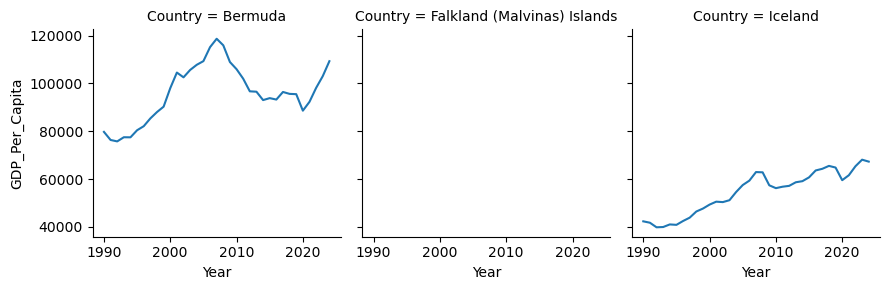

In [75]:
g = sns.FacetGrid(top3_df, col="Country")
g.map(sns.lineplot, "Year", "GDP_Per_Capita")

##### Falkland Islands weren't originally in the GDP database, so there is no data for its GDP. ICeland and Bermuda's GDP dipped in 2020. The look like they were both on a steady incline. Bermuda had a peak in the late 2000s and a dip drastically aftewards.

#### 22. Subset `gdp_and_internet_use` to just the year 2014. Save this as a new dataframe named `gdp_and_internet_use_2014`.

In [76]:
gdp_and_internet_use.loc[gdp_and_internet_use['Year'] == 2014]

,Country,Year,GDP_Per_Capita,Internet_Users_Pct
15,Afghanistan,2014,3017.942544,7.0000
49,Africa Eastern and Southern,2014,4185.238411,NaN
84,Africa Western and Central,2014,6174.703316,NaN
119,Albania,2014,12718.284760,54.3000
154,Algeria,2014,15073.762940,29.5000
...,...,...,...,...
9638,West Bank and Gaza,2014,5990.426615,NaN
9673,World,2014,17492.498902,NaN
9703,Yemen,2014,NaN,22.5500
9734,Zambia,2014,3585.577485,6.5000


In [77]:
gdp_and_internet_use_2014 = gdp_and_internet_use.loc[gdp_and_internet_use['Year'] == 2014]
gdp_and_internet_use_2014

,Country,Year,GDP_Per_Capita,Internet_Users_Pct
15,Afghanistan,2014,3017.942544,7.0000
49,Africa Eastern and Southern,2014,4185.238411,NaN
84,Africa Western and Central,2014,6174.703316,NaN
119,Albania,2014,12718.284760,54.3000
154,Algeria,2014,15073.762940,29.5000
...,...,...,...,...
9638,West Bank and Gaza,2014,5990.426615,NaN
9673,World,2014,17492.498902,NaN
9703,Yemen,2014,NaN,22.5500
9734,Zambia,2014,3585.577485,6.5000


#### 23. Create a plot which compares Internet Users Percentage and GDP per Capita for the year 2014. What do you notice from this plot? If you see any unusual points, investigate them.

<Axes: xlabel='GDP_Per_Capita', ylabel='Internet_Users_Pct'>

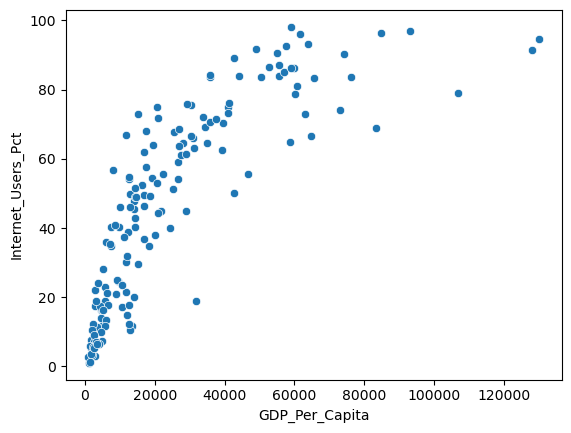

In [78]:
sns.scatterplot(gdp_and_internet_use_2014, x="GDP_Per_Capita", y="Internet_Users_Pct")

##### As GDP_Per_Capita increases, so does Internet_Use_Pct. 